# Notebook 02 — TF-IDF + Logistic Regression Baseline

**Project:** MarketMind AI — Review Intelligence for Marketing Generation  
**Author:** Will  
**Date:** March 2026  

**Purpose:**
1. Load the 50K multi-category review dataset from Google Drive
2. Perform a product-aware train/test split (no product appears in both sets)
3. Train a TF-IDF + Logistic Regression classifier with class weighting
4. Evaluate: accuracy, macro F1, per-class F1, confusion matrix
5. Run error analysis on misclassified reviews
6. Save the trained model to Google Drive

**Input:** `data/raw/reviews_50k.parquet`  
**Output:** Trained baseline model + evaluation metrics

#### 1. Setup

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import GroupShuffleSplit

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
from google.colab import drive
drive.mount("/content/drive")

PROJECT_ROOT = "/content/drive/MyDrive/LAU FINAL PROJECT"
DATA_RAW = os.path.join(PROJECT_ROOT, "data", "raw")
DATA_PROCESSED = os.path.join(PROJECT_ROOT, "data", "processed")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")

Mounted at /content/drive


#### 2. Load Data

In [3]:
df = pd.read_parquet(os.path.join(DATA_RAW, "reviews_50k.parquet"))

print(f"Loaded {len(df):,} reviews")
print(f"Columns: {df.columns.tolist()}")
print(f"\nSentiment distribution:")
print(df["sentiment"].value_counts())
print(f"\nCategories: {df['category'].nunique()}")
print(f"Unique products: {df['parent_asin'].nunique():,}")

Loaded 49,989 reviews
Columns: ['asin', 'parent_asin', 'rating', 'text', 'title', 'sentiment', 'text_length', 'category', 'verified_purchase', 'helpful_vote', 'timestamp']

Sentiment distribution:
sentiment
positive    42253
negative     4526
neutral      3210
Name: count, dtype: int64

Categories: 10
Unique products: 4,173


#### 3. Product-Aware Train/Test Split

All reviews for a given product go entirely into train or test — never both. This prevents the model from learning product-specific language and reporting inflated accuracy.

We use an 80/20 split grouped by `parent_asin`.

In [4]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(df, groups=df["parent_asin"]))

train_df = df.iloc[train_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

# Verify no product leakage
train_products = set(train_df["parent_asin"])
test_products = set(test_df["parent_asin"])
overlap = train_products & test_products

print(f"Train: {len(train_df):,} reviews ({len(train_products):,} products)")
print(f"Test:  {len(test_df):,} reviews ({len(test_products):,} products)")
print(f"Product overlap: {len(overlap)} (should be 0)")

print(f"\nTrain sentiment distribution:")
print(train_df["sentiment"].value_counts(normalize=True).round(3))
print(f"\nTest sentiment distribution:")
print(test_df["sentiment"].value_counts(normalize=True).round(3))

Train: 39,484 reviews (3,338 products)
Test:  10,505 reviews (835 products)
Product overlap: 0 (should be 0)

Train sentiment distribution:
sentiment
positive    0.847
negative    0.089
neutral     0.064
Name: proportion, dtype: float64

Test sentiment distribution:
sentiment
positive    0.839
negative    0.095
neutral     0.066
Name: proportion, dtype: float64


#### 4. TF-IDF Vectorization

In [5]:
tfidf = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    strip_accents="unicode",
    sublinear_tf=True,
)

X_train = tfidf.fit_transform(train_df["text"])
X_test = tfidf.transform(test_df["text"])

y_train = train_df["sentiment"]
y_test = test_df["sentiment"]

print(f"TF-IDF vocabulary size: {len(tfidf.vocabulary_):,}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

TF-IDF vocabulary size: 50,000
X_train shape: (39484, 50000)
X_test shape:  (10505, 50000)


#### 5. Train Logistic Regression

Using `class_weight='balanced'` to handle the 13:1 class imbalance. Without this, the model would predict "positive" for nearly everything and still get ~84% accuracy.

In [6]:
%%time

model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    C=1.0,
    solver="lbfgs",
    random_state=42,
)

model.fit(X_train, y_train)
print("Training complete.")

Training complete.
CPU times: user 21.3 s, sys: 25.7 ms, total: 21.3 s
Wall time: 12.6 s


#### 6. Evaluation

In [7]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print("=" * 50)
print("  TF-IDF + Logistic Regression — Test Results")
print("=" * 50)
print(f"\n  Accuracy:  {accuracy:.4f}")
print(f"  Macro F1:  {macro_f1:.4f}")
print(f"\n{'-' * 50}")
print("\nPer-class report:")
print(classification_report(y_test, y_pred, digits=4))

  TF-IDF + Logistic Regression — Test Results

  Accuracy:  0.8310
  Macro F1:  0.6107

--------------------------------------------------

Per-class report:
              precision    recall  f1-score   support

    negative     0.5517    0.6600    0.6010       994
     neutral     0.2457    0.4267    0.3118       696
    positive     0.9593    0.8822    0.9192      8815

    accuracy                         0.8310     10505
   macro avg     0.5856    0.6563    0.6107     10505
weighted avg     0.8734    0.8310    0.8488     10505



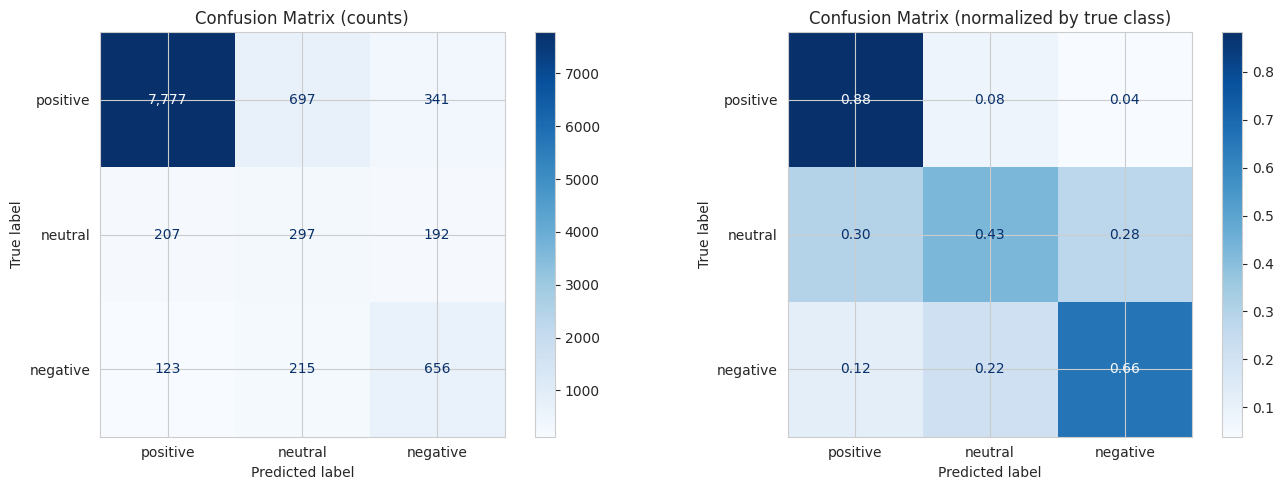

In [8]:
# Confusion matrix
labels = ["positive", "neutral", "negative"]
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=axes[0], cmap="Blues", values_format=",d")
axes[0].set_title("Confusion Matrix (counts)")

# Normalized (recall per class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm, display_labels=labels).plot(ax=axes[1], cmap="Blues", values_format=".2f")
axes[1].set_title("Confusion Matrix (normalized by true class)")

plt.tight_layout()
plt.show()

#### 7. Error Analysis

Look at misclassified reviews to understand failure modes. The neutral class is expected to be the noisiest.

In [9]:
test_df_eval = test_df.copy()
test_df_eval["predicted"] = y_pred
test_df_eval["correct"] = test_df_eval["sentiment"] == test_df_eval["predicted"]

misclassified = test_df_eval[~test_df_eval["correct"]]
print(f"Total misclassified: {len(misclassified):,} / {len(test_df_eval):,} ({len(misclassified)/len(test_df_eval)*100:.1f}%)")

# Breakdown of misclassification patterns
error_patterns = misclassified.groupby(["sentiment", "predicted"]).size().reset_index(name="count")
error_patterns = error_patterns.sort_values("count", ascending=False)
print(f"\nTop error patterns (true → predicted):")
print("-" * 45)
for _, row in error_patterns.iterrows():
    print(f"  {row['sentiment']:>10} → {row['predicted']:<10} : {row['count']:>5,}")

Total misclassified: 1,775 / 10,505 (16.9%)

Top error patterns (true → predicted):
---------------------------------------------
    positive → neutral    :   697
    positive → negative   :   341
    negative → neutral    :   215
     neutral → positive   :   207
     neutral → negative   :   192
    negative → positive   :   123


In [10]:
# Sample misclassified reviews for each major error pattern
top_errors = error_patterns.head(4)

for _, row in top_errors.iterrows():
    true_label = row["sentiment"]
    pred_label = row["predicted"]
    subset = misclassified[
        (misclassified["sentiment"] == true_label) &
        (misclassified["predicted"] == pred_label)
    ].sample(min(3, row["count"]), random_state=42)

    print(f"\n{'=' * 60}")
    print(f"  TRUE: {true_label} → PREDICTED: {pred_label} ({row['count']} cases)")
    print(f"{'=' * 60}")
    for _, review in subset.iterrows():
        text = review["text"][:300] + ("..." if len(review["text"]) > 300 else "")
        print(f"\n  [{review['category']}] {review['rating']:.0f} stars")
        print(f"  {text}")
        print()


  TRUE: positive → PREDICTED: neutral (697 cases)

  [Home_and_Kitchen] 4 stars
  I've only used this once so far.  I liked it as the clean up was much easier.  However, the liner did leak a bit, that's why I gave it a 4 star.


  [Health_and_Household] 4 stars
  As far as paper towels go, these are just okay. But when compared to other similar paper towels, they're good. I would say they are comparable to budget priced paper towels.  It's not fair to compare them to the heavy duty ones since they're in different categories. I do like that these are a recycl...


  [Pet_Supplies] 5 stars
  Actually I bought them by mistake . I thought they were bigger,but it worked out better as I  have been wanting to cut back on the treats and this solved it for me.They can still have them only they are smaller it's a win win for all of us.


  TRUE: positive → PREDICTED: negative (341 cases)

  [Tools_and_Home_Improvement] 4 stars
  They are ok. It's only been a few weeks. I'm just glad only one wa

#### 8. Per-Category Performance

Does the model perform differently across product categories?

Per-Category Performance:
------------------------------------------------------------
  Baby_Products                       acc=0.818  F1=0.635  (n=1370)
  Tools_and_Home_Improvement          acc=0.843  F1=0.616  (n=1104)
  Pet_Supplies                        acc=0.864  F1=0.615  (n=1986)
  Toys_and_Games                      acc=0.878  F1=0.613  (n=1055)
  Home_and_Kitchen                    acc=0.846  F1=0.607  (n=988)
  Office_Products                     acc=0.823  F1=0.605  (n=300)
  Sports_and_Outdoors                 acc=0.804  F1=0.599  (n=1073)
  Health_and_Household                acc=0.805  F1=0.595  (n=886)
  Electronics                         acc=0.797  F1=0.590  (n=832)
  Beauty_and_Personal_Care            acc=0.785  F1=0.589  (n=911)


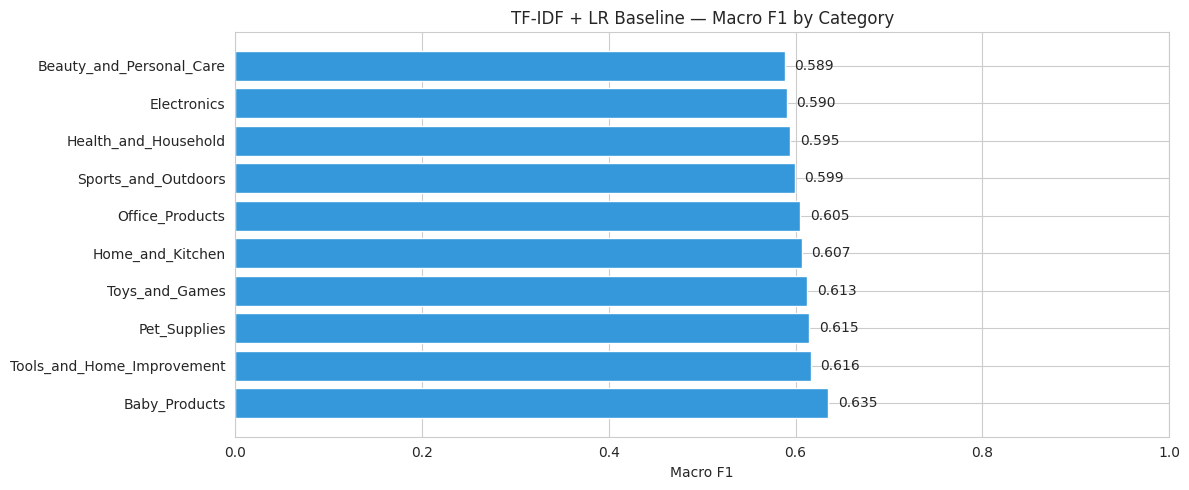

In [11]:
cat_metrics = []
for cat in sorted(test_df_eval["category"].unique()):
    mask = test_df_eval["category"] == cat
    cat_y_true = test_df_eval.loc[mask, "sentiment"]
    cat_y_pred = test_df_eval.loc[mask, "predicted"]
    cat_metrics.append({
        "category": cat,
        "n_reviews": mask.sum(),
        "accuracy": accuracy_score(cat_y_true, cat_y_pred),
        "macro_f1": f1_score(cat_y_true, cat_y_pred, average="macro", zero_division=0),
    })

cat_metrics_df = pd.DataFrame(cat_metrics).sort_values("macro_f1", ascending=False)
print("Per-Category Performance:")
print("-" * 60)
for _, row in cat_metrics_df.iterrows():
    print(f"  {row['category']:<35} acc={row['accuracy']:.3f}  F1={row['macro_f1']:.3f}  (n={row['n_reviews']})")

# Bar chart
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(cat_metrics_df["category"], cat_metrics_df["macro_f1"], color="#3498db")
ax.set_xlabel("Macro F1")
ax.set_title("TF-IDF + LR Baseline — Macro F1 by Category")
ax.set_xlim(0, 1)
for i, (_, row) in enumerate(cat_metrics_df.iterrows()):
    ax.text(row["macro_f1"] + 0.01, i, f"{row['macro_f1']:.3f}", va="center")
plt.tight_layout()
plt.show()

#### 9. Save Model & Vectorizer

In [12]:
# Save model and vectorizer
model_path = os.path.join(MODELS_DIR, "tfidf_lr_baseline.joblib")
vectorizer_path = os.path.join(MODELS_DIR, "tfidf_vectorizer.joblib")

joblib.dump(model, model_path)
joblib.dump(tfidf, vectorizer_path)

model_size = os.path.getsize(model_path) / 1e6
vec_size = os.path.getsize(vectorizer_path) / 1e6

print(f"Model saved to: {model_path} ({model_size:.1f} MB)")
print(f"Vectorizer saved to: {vectorizer_path} ({vec_size:.1f} MB)")

Model saved to: /content/drive/MyDrive/LAU FINAL PROJECT/models/tfidf_lr_baseline.joblib (1.2 MB)
Vectorizer saved to: /content/drive/MyDrive/LAU FINAL PROJECT/models/tfidf_vectorizer.joblib (2.0 MB)


#### 10. Summary

**What this notebook produced:**
- TF-IDF + Logistic Regression baseline with `class_weight='balanced'`
- Product-aware train/test split (no product leakage, 0 overlap confirmed)
- Full evaluation: accuracy, macro F1, per-class F1, confusion matrix
- Error analysis with sample misclassified reviews
- Per-category performance breakdown
- Saved model and vectorizer to Google Drive

**Key metrics:**
- Accuracy: **0.8310**
- Macro F1: **0.6107**
- Positive F1: **0.9192** — strong, easy class
- Negative F1: **0.6010** — decent, picks up complaint language
- Neutral F1: **0.3118** — weak, as expected. 3-star class is genuinely ambiguous.
- Training time: **12.6 seconds**
- Misclassified: 1,775 / 10,505 (16.9%)
- Top error: 697 positive reviews predicted as neutral (hedged praise)

**Next:** DistilBERT fine-tuning (Notebook 03) — compare against this baseline.